In [2]:
from dotenv import load_dotenv
from pathlib import Path
import os

from typing import Annotated
from typing_extensions import TypedDict

from langchain_groq import ChatGroq
from langchain_tavily import TavilySearch
from langchain_core.messages import HumanMessage

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.graph.message import add_messages

from langgraph.checkpoint.memory import MemorySaver
from langgraph.checkpoint.sqlite import SqliteSaver


In [3]:
env_path = Path.cwd().parent / ".env"

print("Loading from:", env_path)

load_dotenv(env_path)

print("TAVILY:", os.getenv("TAVILY_API_KEY") is not None)
print("GROQ:", os.getenv("GROQ_API_KEY") is not None)

Loading from: d:\Gen AI Projects\Agentic_AI_Project\.env
TAVILY: True
GROQ: True


In [4]:
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0
)

In [5]:
# Tavily Search Tool
search_tool = TavilySearch(max_results=2)

# Custom Tool

def multiply(a: int, b: int) -> int:
    """
    Multiply two integers
    """
    return a * b

In [6]:
# Tools list

tools = [
    search_tool,
    multiply]

In [7]:
# Bind tools to LLM

llm_with_tool = llm.bind_tools(tools)

In [8]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [9]:
def tool_calling_llm(state: State):
    return {
        "messages": [
            llm_with_tool.invoke(state["messages"])
        ]
    }

In [10]:
builder = StateGraph(State)

builder.add_node(
    "tool_calling_llm",
    tool_calling_llm
)

builder.add_node(
    "tools",
    ToolNode(tools)
)

In [11]:
builder.add_edge(
    START,
    "tool_calling_llm"
)

builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)

builder.add_edge(
    "tools",
    END
)

In [12]:
# Persistent Memory using SQLite (data saved even after restart)
memory = SqliteSaver.from_conn_string(
    "sqlite:///chatbot_memory.db"
)

print("Persistent SQLite memory initialized: chatbot_memory.db")

Persistent SQLite memory initialized: chatbot_memory.db


In [13]:
memory = MemorySaver()


In [14]:
graph = builder.compile(
    checkpointer=memory
)

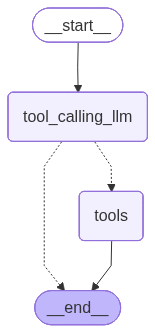

In [15]:
from IPython.display import Image, display

display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)

In [16]:
config = {
    "configurable": {
        "thread_id": "1"
    }
}

response = graph.invoke(
    {
        "messages": [
            ("user", "Hi")
        ]
    },
    config=config
)

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hi
================================== Ai Message ==================================

It seems like you're here to ask questions or get help with something. What's on your mind?


In [17]:
response = graph.invoke(
    {
        "messages": [
            ("user", "What is the recent AI news?")
        ]
    },
    config=config
)

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hi
================================== Ai Message ==================================

It seems like you're here to ask questions or get help with something. What's on your mind?
================================ Human Message =================================

What is the recent AI news?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (w1hx1vpy3)
 Call ID: w1hx1vpy3
  Args:
    query: recent AI news
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://uk.news.yahoo.com/five-post-easter-specters-advancing-021421324.html", "title": "Five Post-Easter Specters Of Advancing AI - Yahoo News UK", "score": 0.7680558, "published_date": "Wed, 15 Apr 2026 02:14

In [18]:
response = graph.invoke(
    {
        "messages": [
            ("user", "What is 5 multiplied by 2?")
        ]
    },
    config=config
)

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hi
================================== Ai Message ==================================

It seems like you're here to ask questions or get help with something. What's on your mind?
================================ Human Message =================================

What is the recent AI news?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (w1hx1vpy3)
 Call ID: w1hx1vpy3
  Args:
    query: recent AI news
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://uk.news.yahoo.com/five-post-easter-specters-advancing-021421324.html", "title": "Five Post-Easter Specters Of Advancing AI - Yahoo News UK", "score": 0.7680558, "published_date": "Wed, 15 Apr 2026 02:14

In [19]:
response = graph.invoke(
    {
        "messages": [
            ("user", "Hi my name is Abhay")
        ]
    },
    config=config
)

response = graph.invoke(
    {
        "messages": [
            ("user", "What is my name?")
        ]
    },
    config=config
)

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hi
================================== Ai Message ==================================

It seems like you're here to ask questions or get help with something. What's on your mind?
================================ Human Message =================================

What is the recent AI news?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (w1hx1vpy3)
 Call ID: w1hx1vpy3
  Args:
    query: recent AI news
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://uk.news.yahoo.com/five-post-easter-specters-advancing-021421324.html", "title": "Five Post-Easter Specters Of Advancing AI - Yahoo News UK", "score": 0.7680558, "published_date": "Wed, 15 Apr 2026 02:14

In [20]:
#Streaming
for chunk in graph.stream(
    {
        "messages": [
            ("user", "Give me latest AI news")
        ]
    },
    config=config
):
    print(chunk)

{'tool_calling_llm': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '69kpemxp7', 'function': {'arguments': '{"query":"latest AI news","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 2618, 'total_tokens': 2642, 'completion_time': 0.022780648, 'completion_tokens_details': None, 'prompt_time': 0.638018461, 'prompt_tokens_details': None, 'queue_time': 0.092772791, 'total_time': 0.660799109}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d8fb2-8a2c-7823-8590-317342cd8077-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'latest AI news', 'topic': 'news'}, 'id': '69kpemxp7', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 2618, 'output_tokens': 24, 'total_tokens': 2642})]}}
{'tool

In [21]:
print("\n--- Streaming Response ---\n")

for chunk in graph.stream(
    {
        "messages": [
            ("user", "Give me the latest AI news and summarize it")
        ]
    },
    config=config
):
    
    if "messages" in chunk:
        last_message = chunk["messages"][-1]
        
        try:
            last_message.pretty_print()
        except Exception:
            print(chunk)

print("\nStreaming completed.")


--- Streaming Response ---


Streaming completed.


In [22]:
from langgraph.checkpoint.sqlite import SqliteSaver
#Confirm SQLite Memory Is Active
memory = SqliteSaver.from_conn_string(
    "sqlite:///chatbot_memory.db"
)

print("SQLite memory initialized")

SQLite memory initialized


In [23]:
config = {
    "configurable": {
        "thread_id": "user_1"
    }
}

response = graph.invoke(
    {
        "messages": [
            ("user", "My name is Abhay")
        ]
    },
    config=config
)

print("Stored name")

Stored name


In [24]:
response = graph.invoke(
    {
        "messages": [
            ("user", "What is my name?")
        ]
    },
    config=config
)

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

My name is Abhay
================================== Ai Message ==================================
Tool Calls:
  tavily_search (jm4f1eb8m)
 Call ID: jm4f1eb8m
  Args:
    query: Abhay
    topic: general
================================= Tool Message =================================
Name: tavily_search

{"query": "Abhay", "response_time": 0.8, "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://en.wikipedia.org/wiki/Abhay_(TV_series)", "title": "Abhay (TV series) - Wikipedia", "content": "The series revolves around officer Abhay Pratap Singh, an investigating officer with the mind of a criminal, who can go to any extent to solve a case.", "score": 0.7610953, "raw_content": null}, {"url": "https://en.wikipedia.org/wiki/Abhay_(1994_film)", "title": "Abhay (1994 film) - Wikipedia", "content": "The 1994 Hindi film Abhay—The Fearless is an adaptation of Oscar Wilde's 1887 sho